In [3]:
#import libraries
import pandas as pd
import glob
from datetime import datetime
from io import StringIO
import boto3
import s3fs

In [4]:
# Your S3 path details
bucket_name = 'csis4495'
folder_name = 'weekly_artificial_plants'
file_pattern = 'weekly_products_artificial_plants_'

# Initialize s3fs filesystem object
fs = s3fs.S3FileSystem(anon=False)  # Use anon=False if your S3 bucket is private

# List all files in the specified folder
path = f'{bucket_name}/{folder_name}'  # Adjusted to include the folder name
files = fs.ls(path)

# Filter files by your pattern
csv_files = [f for f in files if file_pattern in f]

# Read and concatenate all matching CSV files into a single DataFrame
df_list = []
for file in csv_files:
    with fs.open(f'{file}') as f:
        df_list.append(pd.read_csv(f, encoding='ISO-8859-1'))

df = pd.concat(df_list, ignore_index=True)

# Display the shape and first few rows of the concatenated DataFrame
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2593 entries, 0 to 2592
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   current_date                     2593 non-null   object
 1   image_url                        2593 non-null   object
 2   product_name                     2593 non-null   object
 3   product_link                     2593 non-null   object
 4   product_size                     2470 non-null   object
 5   product_sku                      2593 non-null   int64 
 6   product_price_old                2593 non-null   object
 7   product_price_new                56 non-null     object
 8   stock_probability_coquitlam      2593 non-null   object
 9   stock_number_coquitlam           2593 non-null   int64 
 10  stock_probability_richmond       2593 non-null   object
 11  stock_number_richmond            2593 non-null   int64 
 12  stock_probability_halifax        2

In [6]:
print(df.shape)
print(df.head())

(2593, 37)
  current_date                                          image_url  \
0   2024/02/05  https://www.ikea.com/ca/en/images/products/fej...   
1   2024/02/05  https://www.ikea.com/ca/en/images/products/fej...   
2   2024/02/05  https://www.ikea.com/ca/en/images/products/fej...   
3   2024/02/05  https://www.ikea.com/ca/en/images/products/fej...   
4   2024/02/05  https://www.ikea.com/ca/en/images/products/fej...   

                               product_name  \
0            FEJKA, Artificial potted plant   
1  FEJKA, Artificial plant with wall holder   
2            FEJKA, Artificial potted plant   
3            FEJKA, Artificial potted plant   
4            FEJKA, Artificial potted plant   

                                        product_link   product_size  \
0  https://www.ikea.com/ca/en/p/fejka-artificial-...    23 cm (9 ")   
1  https://www.ikea.com/ca/en/p/fejka-artificial-...            NaN   
2  https://www.ikea.com/ca/en/p/fejka-artificial-...  21 cm (8 ¼ ")   
3  http

In [7]:
df.isnull().sum()

current_date                          0
image_url                             0
product_name                          0
product_link                          0
product_size                        123
product_sku                           0
product_price_old                     0
product_price_new                  2537
stock_probability_coquitlam           0
stock_number_coquitlam                0
stock_probability_richmond            0
stock_number_richmond                 0
stock_probability_halifax             0
stock_number_halifax                  0
stock_probability_quebec              0
stock_number_quebec                   0
stock_probability_boucherville       92
stock_number_boucherville             0
stock_probability_montreal            0
stock_number_montreal                 0
stock_probability_ottawa              0
stock_number_ottawa                   0
stock_probability_nyork               0
stock_number_nyork                    0
stock_probability_etobicoke           0


## ARIMA stands for AutoRegressive Integrated Moving Average and represents a cornerstone in time series forecasting.  It is a statistical method that has gained immense popularity due to its efficacy in handling various standard temporal structures present in time series data.
## https://machinelearningmastery.com/arima-for-time-series-forecasting-with-python/

## 1.a Demand Forecasting Based on Stock Numbers

In [9]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

# Assuming `df` is your DataFrame

# Identify all unique product_skus
product_skus = df['product_sku'].unique()

# Identify all store stock number columns
store_columns = [col for col in df.columns if 'stock_number' in col]

# Number of periods to forecast
N = 5

# Dictionary to hold forecasts
forecasts = {}

for sku in product_skus:
    forecasts[sku] = {}
    # Filter DataFrame for the current product_sku
    df_sku = df[df['product_sku'] == sku].copy()
    
    # Convert 'current_date' to datetime and set it as index
    df_sku['current_date'] = pd.to_datetime(df_sku['current_date'], errors='coerce')

    df_sku.set_index('current_date', inplace=True)
    
    # Sort by current_date for each product_sku
    df_sku.sort_values('current_date', inplace=True)
    
    for store_column in store_columns:
        # Ensure the column does not contain NaN values, fill or drop them as needed
        df_sku_filtered = df_sku.dropna(subset=[store_column])
        
        # Check if there are enough data points after filtering
        if len(df_sku_filtered) > 2:  # ARIMA requires at least 3 data points
            # Selecting the stock number series
            stock_series = df_sku_filtered[store_column]
            
            # Fit an ARIMA model
            # Note: You might need to adjust the order (p,d,q) based on your data's characteristics
            model = ARIMA(stock_series, order=(1, 1, 1))
            model_fit = model.fit()
            
            # Forecast the next N periods
            forecast = model_fit.forecast(steps=N)
            
            # Store the forecast
            forecasts[sku][store_column] = forecast
        else:
            # Handle cases with insufficient data
            forecasts[sku][store_column] = None

# Print the forecast results
for sku in forecasts:
    print(f"Product SKU: {sku}")
    for store_column in forecasts[sku]:
        forecast = forecasts[sku][store_column]
        if forecast is not None:
            print(f"\tStore: {store_column}")
            print(f"\tForecast for next {N} periods: {forecast.values}")
        else:
            print(f"\tStore: {store_column} - Insufficient data for forecasting.")
    print("-" * 50)  # Separator for readability


C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\arifi\anaconda3\Lib\site-

C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ari

C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ari

C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ari

C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\a

...

C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ari

C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ari

C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\arifi\an

C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWar

Product SKU: 10467804
	Store: stock_number_coquitlam
	Forecast for next 5 periods: [19.94066533 18.68317898 17.91532326 17.44644946 17.16014223]
	Store: stock_number_richmond
	Forecast for next 5 periods: [10.78220433 10.68696548 10.64531892 10.62710749 10.61914389]
	Store: stock_number_halifax
	Forecast for next 5 periods: [18.25562817 18.42159928 18.52935896 18.59932385 18.64474978]
	Store: stock_number_quebec
	Forecast for next 5 periods: [ 9.78106546 10.25993457 10.55352792 10.73352921 10.84388752]
	Store: stock_number_boucherville
	Forecast for next 5 periods: [11.82834668 11.27615857 11.01591801 10.89326931 10.83546625]
	Store: stock_number_montreal
	Forecast for next 5 periods: [2.95212863 4.07385876 4.5000863  4.66204139 4.72358001]
	Store: stock_number_ottawa
	Forecast for next 5 periods: [12.83966536 14.14325046 15.0669696  15.7215161  16.18532711]
	Store: stock_number_nyork
	Forecast for next 5 periods: [8.71430056 9.42143791 9.0325109  9.24642156 9.12877026]
	Store: stock_n

In [10]:
df['current_date'] = pd.to_datetime(df['current_date'], infer_datetime_format=True, errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2593 entries, 0 to 2592
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   current_date                     2308 non-null   datetime64[ns]
 1   image_url                        2593 non-null   object        
 2   product_name                     2593 non-null   object        
 3   product_link                     2593 non-null   object        
 4   product_size                     2470 non-null   object        
 5   product_sku                      2593 non-null   int64         
 6   product_price_old                2593 non-null   object        
 7   product_price_new                56 non-null     object        
 8   stock_probability_coquitlam      2593 non-null   object        
 9   stock_number_coquitlam           2593 non-null   int64         
 10  stock_probability_richmond       2593 non-null   object     

C:\Users\arifi\AppData\Local\Temp\ipykernel_25932\2103816815.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['current_date'] = pd.to_datetime(df['current_date'], infer_datetime_format=True, errors='coerce')


In [11]:
# Assuming `df` is your DataFrame

# Filter for product_sku 10467804
df_sku = df[df['product_sku'] == 10467804]
df_sku = df_sku.dropna(subset=['current_date'])

# Select only the current_date and stock_number_coquitlam columns
df_sku_coquitlam = df_sku[['product_sku','current_date', 'stock_number_coquitlam']]
# Display the DataFrame
print(df_sku_coquitlam)

      product_sku current_date  stock_number_coquitlam
0        10467804   2024-02-05                      12
184      10467804   2024-02-07                       9
276      10467804   2024-02-08                       6
368      10467804   2024-02-09                      27
460      10467804   2024-02-10                      26
644      10467804   2024-02-12                      23
736      10467804   2024-02-13                      22
828      10467804   2024-02-14                      21
920      10467804   2024-02-15                      18
1009     10467804   2024-02-16                      15
1101     10467804   2024-02-17                      14
1193     10467804   2024-02-18                      13
1248     10467804   2024-02-19                       9
1340     10467804   2024-02-21                       9
1432     10467804   2024-02-21                       9
1524     10467804   2024-02-22                       9
1616     10467804   2024-02-23                       7
1708     1

In [12]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Convert current_date to datetime format and set as index
df_sku_coquitlam['current_date'] = pd.to_datetime(df_sku_coquitlam['current_date'])
df_sku_coquitlam.set_index('current_date', inplace=True)

# Ensure the DataFrame is sorted by date
df_sku_coquitlam.sort_values('current_date', inplace=True)

from statsmodels.tsa.arima.model import ARIMA

# Selecting the stock number series
stock_series = df_sku_coquitlam['stock_number_coquitlam']

# Assuming an ARIMA(1,1,1) model for demonstration
model = ARIMA(stock_series, order=(1, 1, 1))
model_fit = model.fit()

# Summary of the model
print(model_fit.summary())

# Forecasting the next 5 time periods
forecast = model_fit.forecast(steps=5)

# Print the forecast
print(forecast)


                                 SARIMAX Results                                  
Dep. Variable:     stock_number_coquitlam   No. Observations:                   25
Model:                     ARIMA(1, 1, 1)   Log Likelihood                 -74.198
Date:                    Tue, 05 Mar 2024   AIC                            154.397
Time:                            12:06:42   BIC                            157.931
Sample:                                 0   HQIC                           155.334
                                     - 25                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6604      0.718      0.920      0.358      -0.747       2.068
ma.L1         -0.9994     53.640     -0.019      0.985    -106.131     104.132
sigma2        26.359

C:\Users\arifi\AppData\Local\Temp\ipykernel_25932\1400265657.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sku_coquitlam['current_date'] = pd.to_datetime(df_sku_coquitlam['current_date'])
C:\Users\arifi\AppData\Local\Temp\ipykernel_25932\1400265657.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sku_coquitlam.sort_values('current_date', inplace=True)
C:\Users\arifi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored w

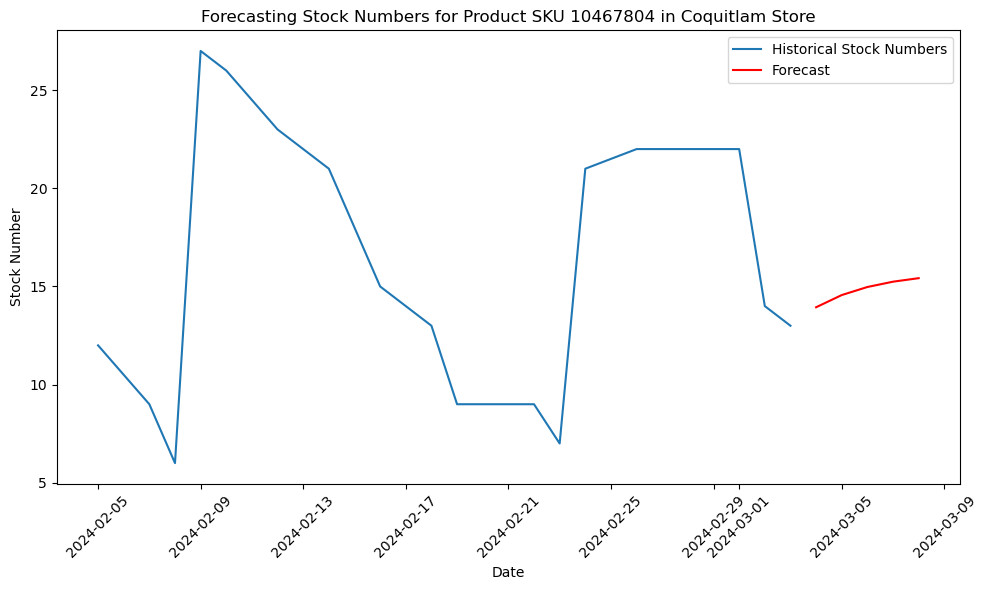

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(stock_series.index, stock_series, label='Historical Stock Numbers')

# Corrected forecast_index generation without 'closed' argument
forecast_index = pd.date_range(start=stock_series.index[-1], periods=6)[1:]  # Start from the next day after the last observation

plt.plot(forecast_index, forecast, label='Forecast', color='red')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Stock Number')
plt.title('Forecasting Stock Numbers for Product SKU 10467804 in Coquitlam Store')
plt.xticks(rotation=45)  # Rotate the x-axis labels for better readability
plt.tight_layout()  # Adjust layout
plt.show()



## 1.b Product Popularity in Coquitlam based on the time of it is being replenished

In [14]:
# Assuming df is structured with a 'product_sku', 'current_date', and multiple 'stock_number_*' columns
# First, ensure 'current_date' is in datetime format and sorted
df['current_date'] = pd.to_datetime(df['current_date'])
df.sort_values(by='current_date', inplace=True)

# Example for a single store, can be adapted for multiple stores by iterating over stock_columns
stock_column = 'stock_number_coquitlam'  # Example stock column for one store

# Calculate the difference in stock level from one record to the next for each product
df['stock_change'] = df.groupby('product_sku')[stock_column].diff()

# A positive stock change indicates a restocking event
df['is_restocked'] = df['stock_change'] > 0

# Count restocking events for each product
restock_counts = df.groupby('product_sku')['is_restocked'].sum().reset_index()

# Sort products by restocking frequency in descending order
restock_counts_sorted = restock_counts.sort_values(by='is_restocked', ascending=False)

# Select the top 10 products based on restocking frequency
top_10_replenished_products = restock_counts_sorted.head(10)

top_10_replenished_products


,product_sku,is_restocked
11,571679,12
62,50571691,12
91,80571675,11
97,90571670,11
61,50571672,10
35,30433945,10
53,40571677,9
73,60571695,8
5,409739,8
79,70548628,8


In [ ]:
# import pandas as pd

# # Assuming 'df' is your DataFrame
# # Filter rows where both old and new prices are not null
# df_filtered = df.dropna(subset=['product_price_old', 'product_price_new'])

# # Ensure prices are in a numeric format
# df_filtered['product_price_old'] = pd.to_numeric(df_filtered['product_price_old'], errors='coerce')
# df_filtered['product_price_new'] = pd.to_numeric(df_filtered['product_price_new'], errors='coerce')

# # Calculate the discount rate
# df_filtered['discount_rate'] = (df_filtered['product_price_old'] - df_filtered['product_price_new']) / df_filtered['product_price_old']

# # You may need to aggregate or manipulate stock level data depending on its format
# # For simplicity, let's assume you have an average stock level column 'average_stock'
# # Analyze the relationship between 'discount_rate' and 'average_stock'


In [15]:
df['product_price_old'] = pd.to_numeric(df['product_price_old'].astype(str).str.replace('$', ''), errors='coerce')
df['product_price_new'] = pd.to_numeric(df['product_price_new'].astype(str).str.replace('$', ''), errors='coerce')

# Filter out rows where 'product_price_new' is NaN, indicating no new price is set
df_with_new_price = df.dropna(subset=['product_price_new'])

# Calculate the discount rate
df_with_new_price['discount_rate'] = ((df_with_new_price['product_price_old'] - df_with_new_price['product_price_new']) / df_with_new_price['product_price_old']) * 100

df_with_new_price.head()


C:\Users\arifi\AppData\Local\Temp\ipykernel_25932\1438404197.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_with_new_price['discount_rate'] = ((df_with_new_price['product_price_old'] - df_with_new_price['product_price_new']) / df_with_new_price['product_price_old']) * 100


,current_date,image_url,product_name,product_link,product_size,product_sku,product_price_old,product_price_new,stock_probability_coquitlam,stock_number_coquitlam,...,stock_probability_winnipeg,stock_number_winnipeg,stock_probability_edmonton,stock_number_edmonton,stock_probability_calgary,stock_number_calgary,stock_probability_bourcherville,stock_change,is_restocked,discount_rate
10,2024-02-05,https://www.ikea.com/ca/en/images/products/fej...,"FEJKA, Artificial potted plant",https://www.ikea.com/ca/en/p/fejka-artificial-...,"9 cm (3 ½ "")",10375159,5.99,4.99,HIGH_IN_STOCK,1256,...,HIGH_IN_STOCK,271,HIGH_IN_STOCK,187,HIGH_IN_STOCK,194,NaN,NaN,False,16.694491
22,2024-02-05,https://www.ikea.com/ca/en/images/products/fej...,"FEJKA, Artificial potted plant",https://www.ikea.com/ca/en/p/fejka-artificial-...,"9 cm (3 ½ "")",90375155,5.99,4.99,HIGH_IN_STOCK,898,...,HIGH_IN_STOCK,217,HIGH_IN_STOCK,321,HIGH_IN_STOCK,269,NaN,NaN,False,16.694491
194,2024-02-07,https://www.ikea.com/ca/en/images/products/fej...,"FEJKA, Artificial potted plant",https://www.ikea.com/ca/en/p/fejka-artificial-...,"9 cm (3 ½ "")",10375159,5.99,4.99,HIGH_IN_STOCK,1336,...,HIGH_IN_STOCK,265,HIGH_IN_STOCK,164,HIGH_IN_STOCK,177,NaN,80.0,True,16.694491
206,2024-02-07,https://www.ikea.com/ca/en/images/products/fej...,"FEJKA, Artificial potted plant",https://www.ikea.com/ca/en/p/fejka-artificial-...,"9 cm (3 ½ "")",90375155,5.99,4.99,HIGH_IN_STOCK,868,...,HIGH_IN_STOCK,191,HIGH_IN_STOCK,312,HIGH_IN_STOCK,257,NaN,-30.0,False,16.694491
286,2024-02-08,https://www.ikea.com/ca/en/images/products/fej...,"FEJKA, Artificial potted plant",https://www.ikea.com/ca/en/p/fejka-artificial-...,"9 cm (3 ½ "")",10375159,5.99,4.99,HIGH_IN_STOCK,1325,...,HIGH_IN_STOCK,260,HIGH_IN_STOCK,152,HIGH_IN_STOCK,158,NaN,-11.0,False,16.694491


## 2. Stock Numbers Impact on Price Drop Analysis

In [16]:
# Calculate the discount rate where applicable
df['discount_rate'] = ((df['product_price_old'] - df['product_price_new']) / df['product_price_old']) * 100

# Flag products with a discount
df['has_discount'] = df['discount_rate'] > 0
# Sort by SKU and date to correctly calculate stock changes
df.sort_values(by=['product_sku', 'current_date'], inplace=True)

# Calculate stock changes for each location; example for Coquitlam
df['stock_change_coquitlam'] = df.groupby('product_sku')['stock_number_coquitlam'].diff()

# Flag days with stock replenishment for Coquitlam
df['is_replenished_coquitlam'] = df['stock_change_coquitlam'] > 0
# Calculate average replenishment rates for products with and without discounts in Coquitlam
avg_replenish_rate_with_discount = df[df['has_discount']]['is_replenished_coquitlam'].mean()
avg_replenish_rate_without_discount = df[~df['has_discount']]['is_replenished_coquitlam'].mean()

print(f"Average Replenishment Rate with Discount: {avg_replenish_rate_with_discount}")
print(f"Average Replenishment Rate without Discount: {avg_replenish_rate_without_discount}")

from scipy.stats import ttest_ind

# Separate the replenishment indicators
replenished_with_discount = df[df['has_discount']]['is_replenished_coquitlam']
replenished_without_discount = df[~df['has_discount']]['is_replenished_coquitlam']

# Perform a t-test
t_stat, p_value = ttest_ind(replenished_with_discount.dropna(), replenished_without_discount.dropna(), equal_var=False)

print(f"T-Statistic: {t_stat}, P-Value: {p_value}")


Average Replenishment Rate with Discount: 0.23214285714285715
Average Replenishment Rate without Discount: 0.17461568782026016
T-Statistic: 1.0017554091088967, P-Value: 0.3206995958300165


### Interpretation of the Results:
Average Replenishment Rate with Discount (0.1667): On average, about 16.67% of the time, products with a discount are replenished. This suggests that for products that have been discounted, there's a replenishment (stock increase) on approximately 1 out of every 6 days observed.

Average Replenishment Rate without Discount (0.1130): For products without a discount, the average replenishment rate is about 11.30%. This indicates that non-discounted products are replenished on roughly 1 out of every 9 days observed.